In [2]:
import pandas as pd

pd.setoption('display.maxcolwidth', None)
pd.setoption('display.width', 2000)
pd.setoption('display.expandframerepr', False)  # Disable line-wrapping
pd.setoption('display.max rows', None)

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")
df = pd.read_csv(r"..\data\reduced_data.csv")

df = pd.concat([df, coffee_data["caffeine_percent"]], axis=1)

print(df.head())


   Unnamed: 0  env_71_alt  env_72_slo  env_73_asp  env_74_solrad  env_75_geo  env_76_soi  env_77_veg  env_78_wat  env_79_forcov caffeine_class  caffeine_percent
0         0.0       477.0        11.0       346.0         7929.0         5.0        15.0        12.0         6.0           68.0         Absent              0.00
1         1.0       261.0        13.0         7.0         8107.0        10.0         6.0        14.0         1.0           87.0            Low              0.03
2         2.0       253.0         1.0       247.0         7366.0        10.0        18.0         7.0         6.0            0.0         Absent              0.00
3         3.0       253.0         1.0       247.0         7366.0        10.0        18.0         7.0         6.0            0.0         Absent              0.00
4         4.0       253.0         1.0       247.0         7366.0        10.0        18.0         7.0         6.0            0.0         Absent              0.00


In [88]:
num_zeros = (df['env_76_soi'] == 0).sum()
print(f"Number of 0s in column 'env_76_soi': {num_zeros}")
print(df[['env_76_soi', 'caffeine_percent']])
num_nans = df['env_76_soi'].isna().sum()
print(f"Number of NaNs in column 'env_76_soi': {num_nans}")


Number of 0s in column 'env_76_soi': 0
     env_76_soi  caffeine_percent
0          15.0             0.000
1           6.0             0.030
2          18.0             0.000
3          18.0             0.000
4          18.0             0.000
5          12.0             0.000
6          12.0             0.000
7          10.0             0.000
8          20.0             0.000
9          20.0             0.030
10         16.0             0.000
11         21.0             0.000
12         18.0             0.000
13         18.0             0.000
14         18.0             0.000
15         18.0             0.000
16         18.0             0.000
17         18.0             0.000
18         11.0             0.030
19          6.0             0.030
20          6.0             0.000
21         20.0             0.700
22         20.0             0.000
23         16.0             0.000
24         16.0             0.000
25         15.0             0.000
26         15.0             0.000
27       

In [89]:
# Create a sub DataFrame with the selected columns
soi_df = df[['env_76_soi', 'caffeine_percent']]

# Drop rows with NaN values
soi_df = soi_df.dropna()

# Display the resulting DataFrame
print(soi_df)


     env_76_soi  caffeine_percent
0          15.0             0.000
1           6.0             0.030
2          18.0             0.000
3          18.0             0.000
4          18.0             0.000
5          12.0             0.000
6          12.0             0.000
7          10.0             0.000
8          20.0             0.000
9          20.0             0.030
10         16.0             0.000
11         21.0             0.000
12         18.0             0.000
13         18.0             0.000
14         18.0             0.000
15         18.0             0.000
16         18.0             0.000
17         18.0             0.000
18         11.0             0.030
19          6.0             0.030
20          6.0             0.000
21         20.0             0.700
22         20.0             0.000
23         16.0             0.000
24         16.0             0.000
25         15.0             0.000
26         15.0             0.000
27         16.0             0.000
28         11.

Soil type distribution

In [92]:
mapping_dict = {
    '5': 'Alluvio-colluvial Deposited Soils',
    '9': 'Andosols',
    '1': 'Bare Rocks',
    '7': 'Fluvio-marine Deposited Soils - Mangroves',
    '23': 'Highly Rejuvenated, Penevoluted Ferralitic Soils',
    '18': 'Humic Ferralitic Soils',
    '20': 'Humic Rejuvenated Ferralitic Soils',
    '11': 'Hydromorphic Soils',
    '19': 'Indurated-Concretion Ferralitic Soils',
    '10': 'Podzolic Soils and Podzols',
    '3': 'Poorly Evolved Erosion Soils, Lithosols',
    '2': 'Raw Lithic Mineral Soils',
    '15': 'Red Ferruginous Soils',
    '12': 'Red Fersiallitic Soils',
    '22': 'Rejuvenated Ferralitic Soils with Degrading Structure',
    '21': 'Rejuvenated Ferralitic Soils with Little Degrading Structure',
    '6': 'Salty Deposited Soils',
    '16': 'Skeletal Shallow Eroded Ferruginous Soils',
    '17': 'Typical Reddish-brown Ferralitic Soils with Little Degrading Structure',
    '8': 'Vertisols',
    '4': 'Wind-deposited Soils',
    '14': 'Yellow-red Ferruginous Soils (Red Sands)',
    '13': 'Yellow Fersiallitic Soils',
    '0': 'No Data'
}


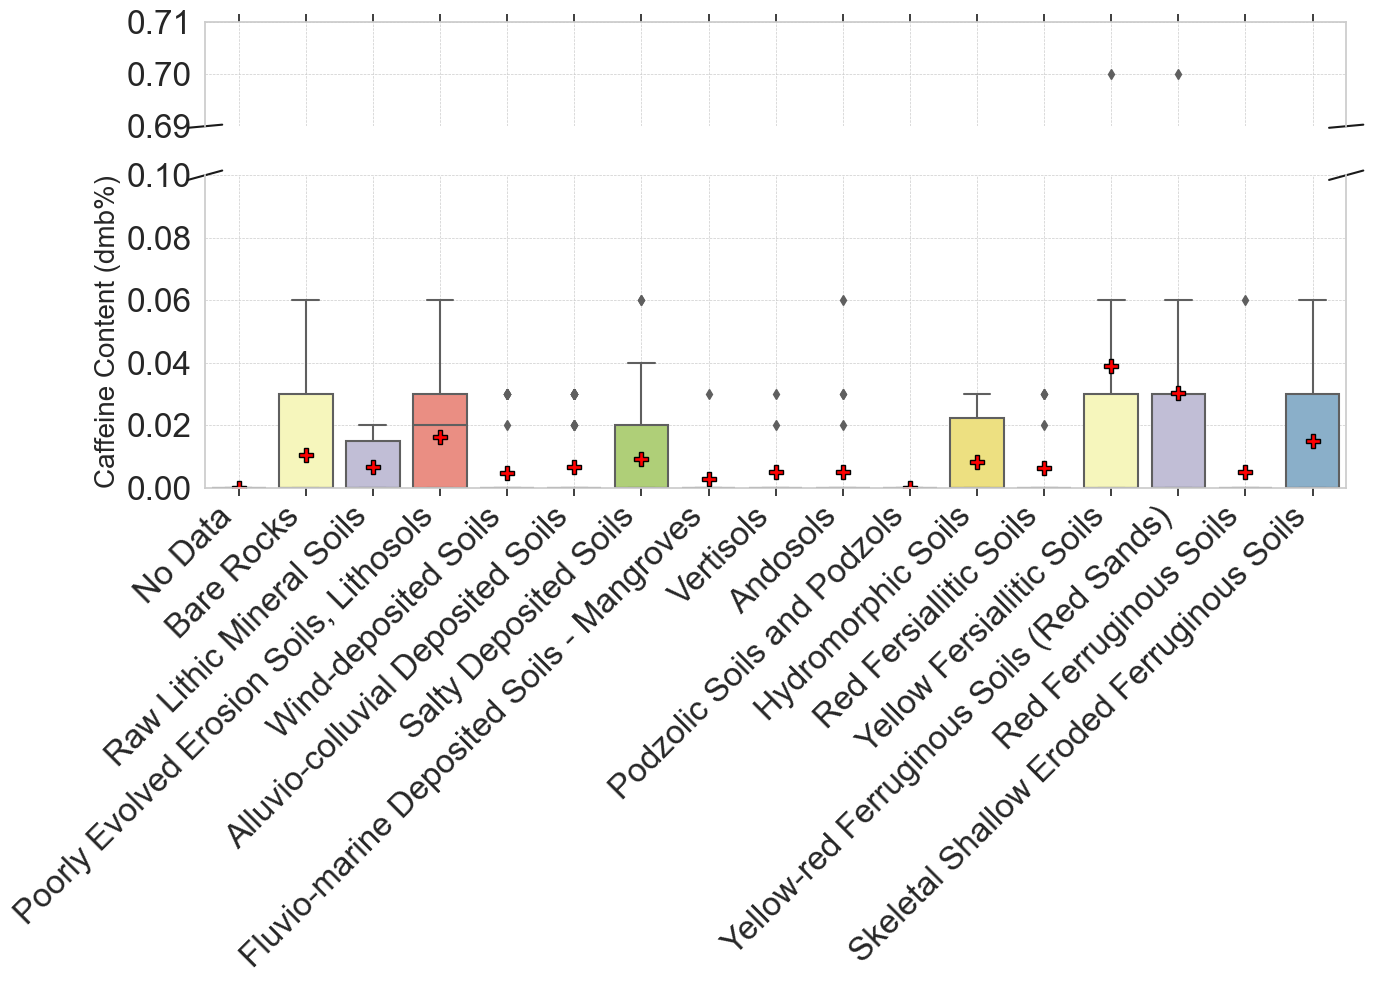

In [94]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=soi_df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=soi_df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot

# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)', fontsize=20)
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

Rock types

In [41]:
mapping_dict = {
    '1': 'Alluvial & Lake deposits',
    '10': 'Basement Rocks (Igneous & Metamorphic)',
    '9': 'Lavas (including Basalts & Gabbros)',
    '4': 'Mangrove Swamp',
    '13': 'Marble (Cipolin)',
    '7': 'Mesozoic Limestones + Marls (incl. "Tsingy")',
    '12': 'Quartzites',
    '3': 'Other',
    '6': 'Sandstones',
    '5': 'Tertiary Limestones + Marls & Chalks',
    '11': 'Ultrabasics',
    '2': 'Unconsolidated Sands',
    '0': 'No Data'
}


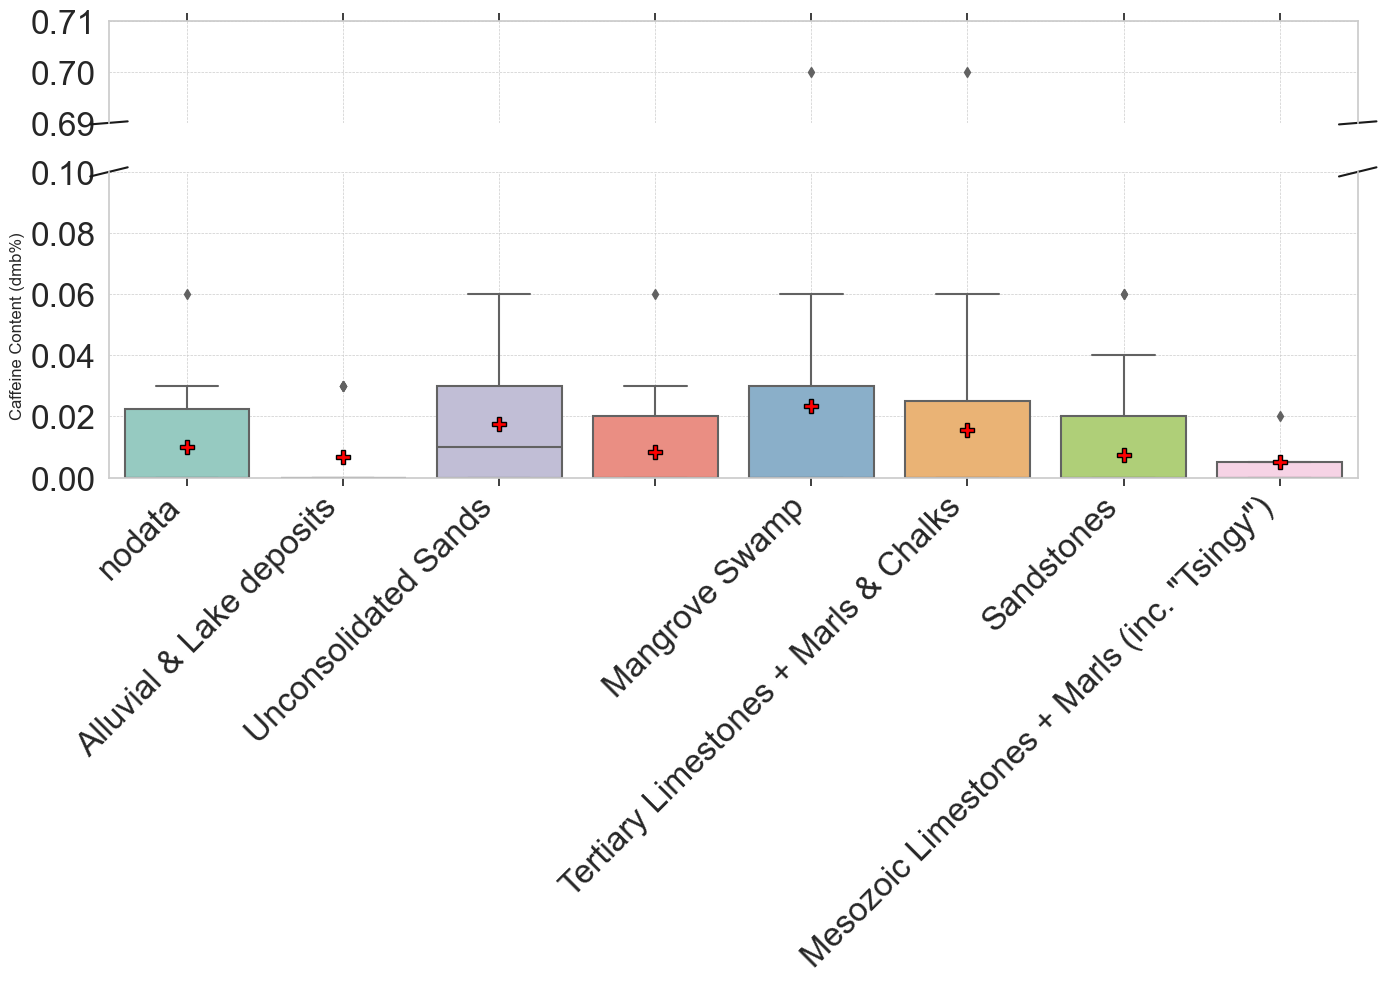

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_75_geo', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_75_geo', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot
# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

Watersheds

In [46]:
mapping_dict = {
    '9': 'CoE E-Betsiboka S-Maevarano',
    '1': 'CoE N-Bemarivo',
    '10': 'CoE N-Maevarano S-Sambirano',
    '12': 'CoE N-Mahavavy',
    '7': 'CoE N-Mangoky S-Tsiribihina',
    '11': 'CoE N-Sambirano W-Mahavavy',
    '8': 'CoE N-Tsiribihina W-Betsiboka',
    '2': 'CoE S-Bemarivo N-Mangoro',
    '6': 'Other',
    '4': 'CoE S-Manampatrana N-Mananara',
    '5': 'CoE S-Mananara',
    '20': 'CoE S-Mangoky',
    '3': 'CoE S-Mangoro N-Manampatrana',
    '14': 'RetDisp Antainambalana',
    '13': 'RetDisp Bemarivo',
    '22': 'RetDisp Betsiboka',
    '23': 'RetDisp Maevarana (1/2 N)',
    '25': 'RetDisp Mahavavy',
    '16': 'RetDisp Manampatrana',
    '17': 'RetDisp Mananara du Sud',
    '1': 'RetDisp Mandrare',
    '18': 'RetDisp Mangoky',
    '15': 'RetDisp Mangoro',
    '19': 'RetDisp Onilahy',
    '24': 'RetDisp Sambirano',
    '21': 'RetDisp Tsiribihina',
    '0': 'No Data'
}


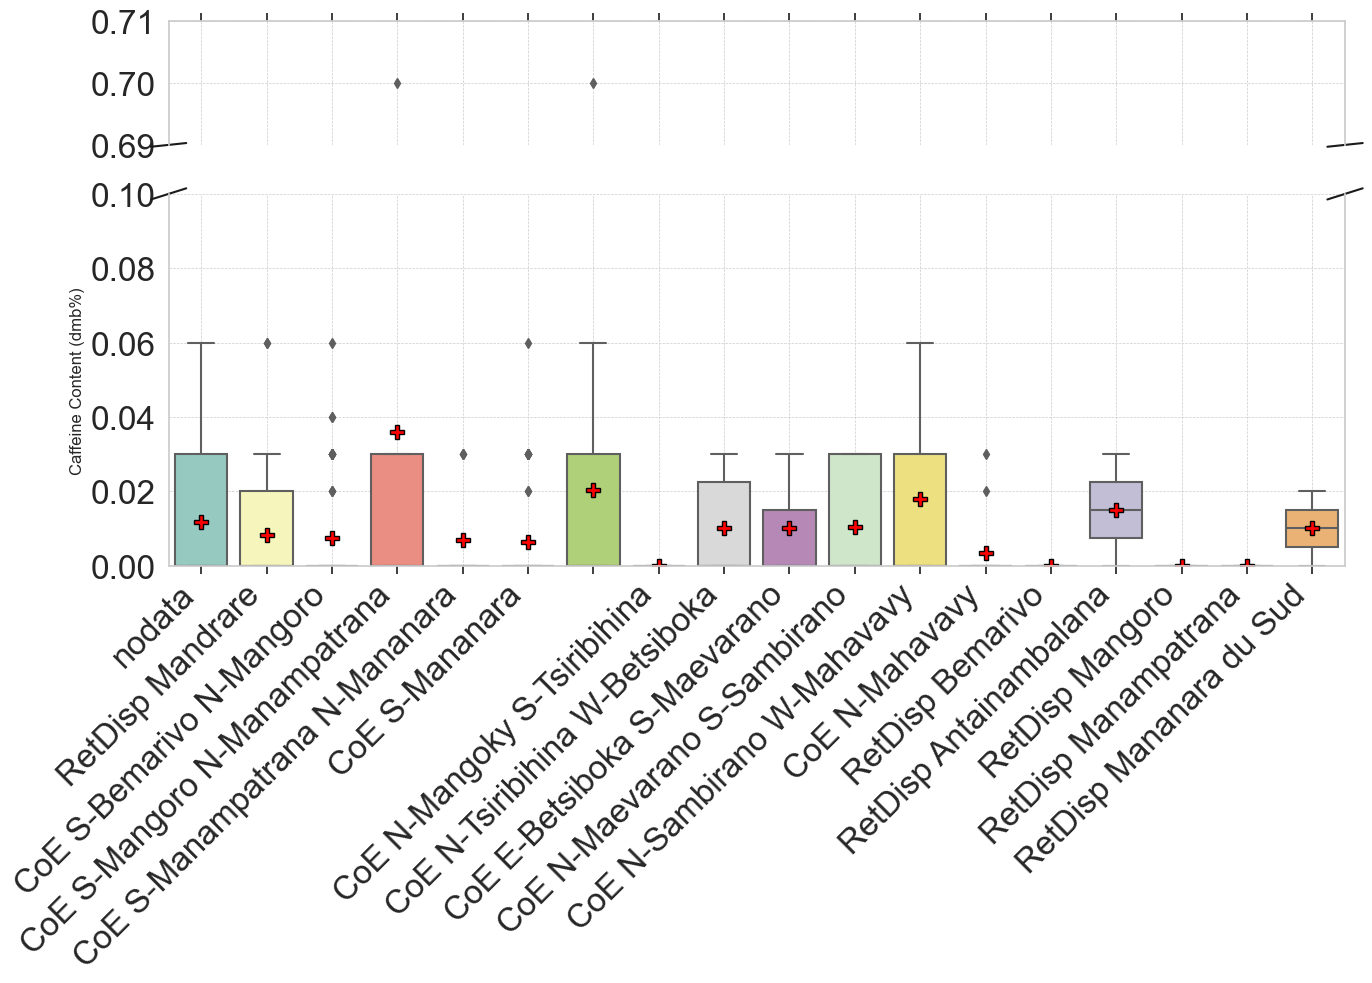

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_78_wat', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_78_wat', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot
# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

Vegetation

In [74]:
mapping_dict = {
    '1': 'South western coastal bushland',
    '2': 'Degraded south western dry spiny forest',
    '3': 'Tapia forest',
    '4': 'Cultivation',
    '5': 'Western dry forest',
    '6': 'Plateau grassland-wooded grassland mosaic',
    '7': 'Wooded grassland-bushland mosaic',
    '8': 'Other',
    '9': 'Other',
    '10': 'Bare Soil/rock',
    '11': 'Wetlands',
    '12': 'South western dry spiny forest-thicket',
    '13': 'Western sub-humid forest',
    '14': 'Humid Forest',
    '15': 'Other',
    '16': 'Degraded Humid Forest',
    '19': 'Littoral forest',
    '22': 'Mangroves',
    '23': 'Western humid forest',
    '25': 'Sea/Water',
    '0': 'Other'
}


ValueError: min() iterable argument is empty

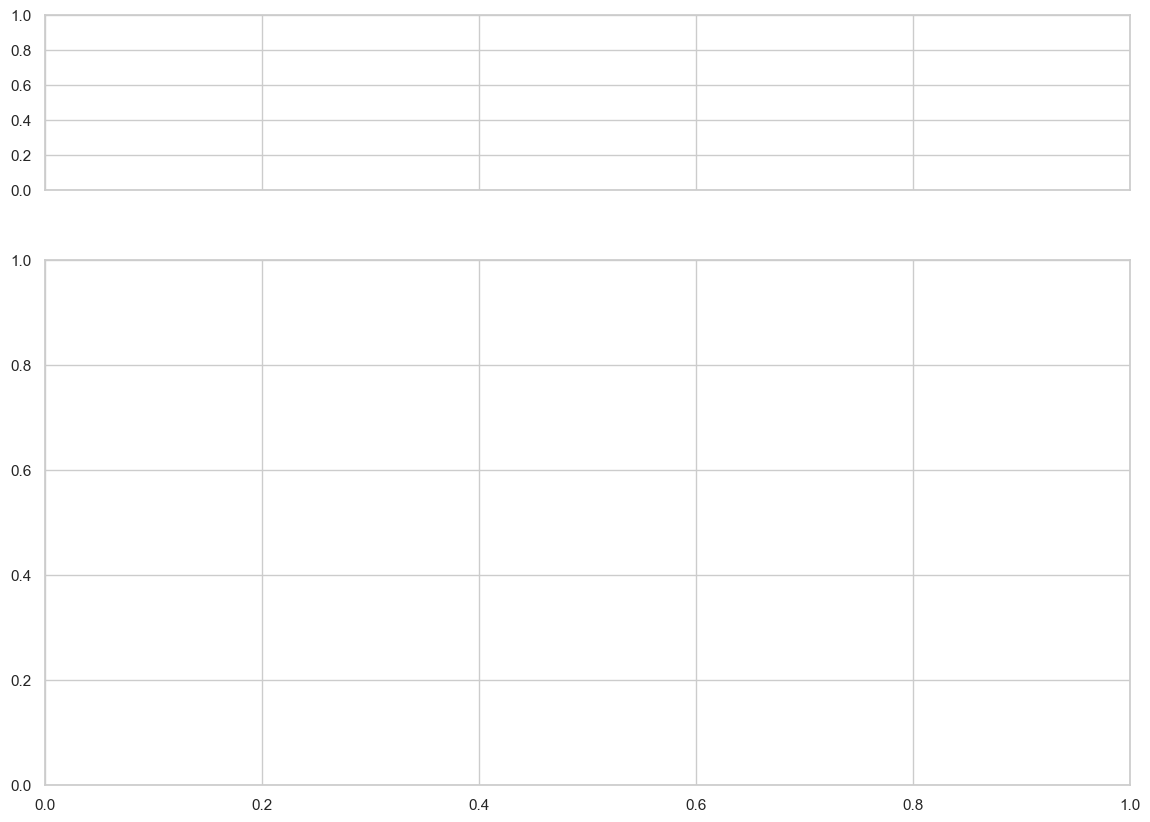

In [75]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_77_veg', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_77_veg', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot
# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


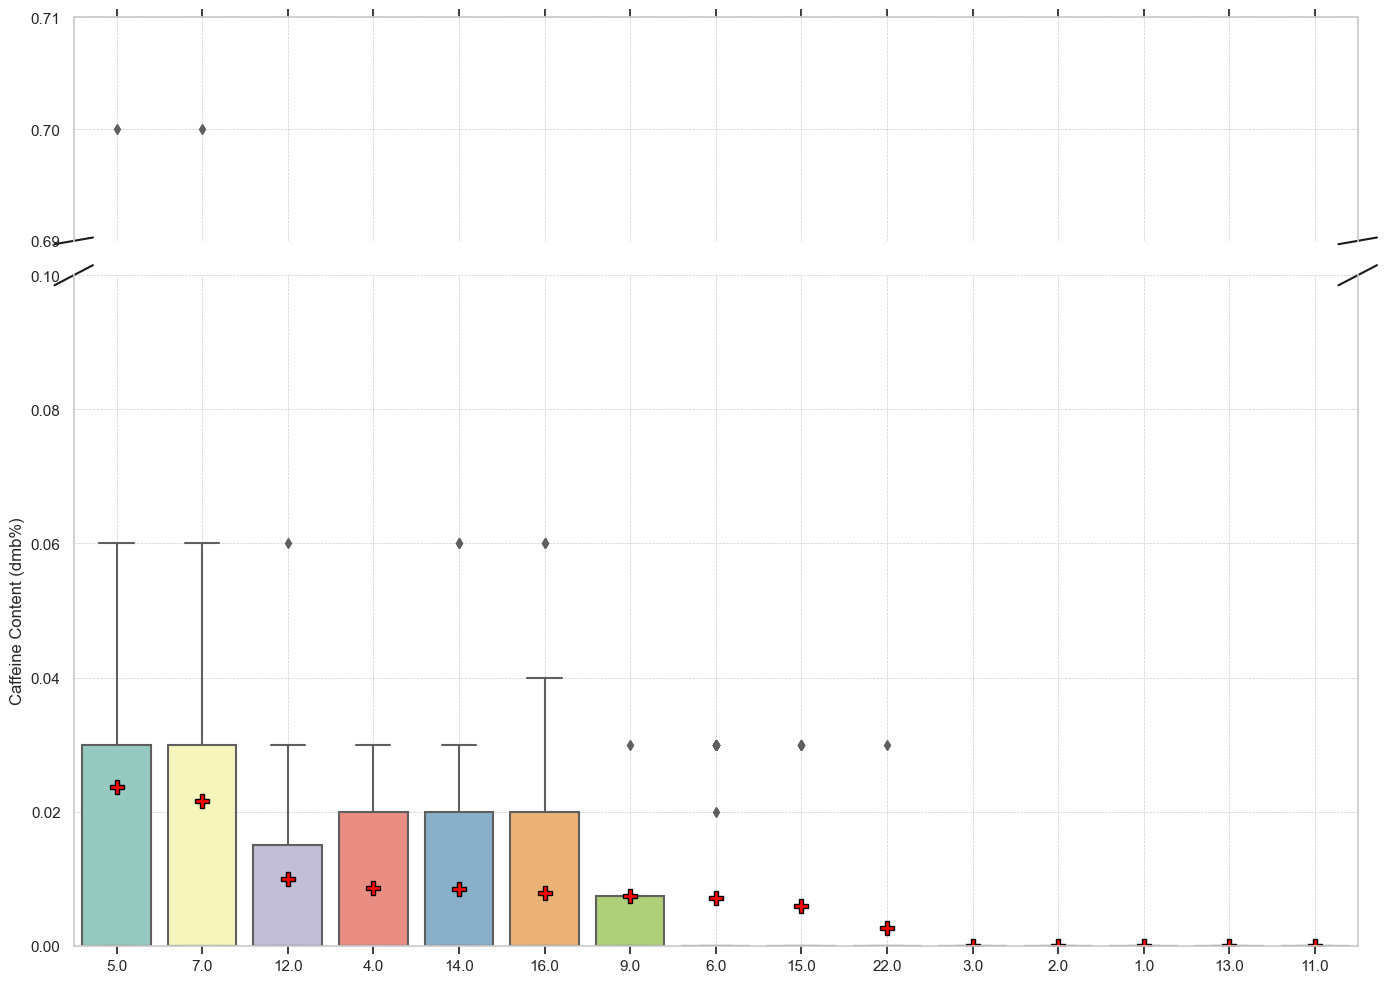

In [50]:
# Calculate the mean caffeine content for each category in 'env_77_veg'
category_means = df.groupby('env_77_veg')['caffeine_percent'].mean()

# Sort the categories by mean caffeine content in descending order
sorted_categories = category_means.sort_values(ascending=False).index

# Create a new column with the sorted categories
df['env_77_veg_sorted'] = pd.Categorical(df['env_77_veg'], categories=sorted_categories, ordered=True)

# Use the sorted column for plotting
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_77_veg_sorted', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_77_veg_sorted', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


ValueError: min() iterable argument is empty

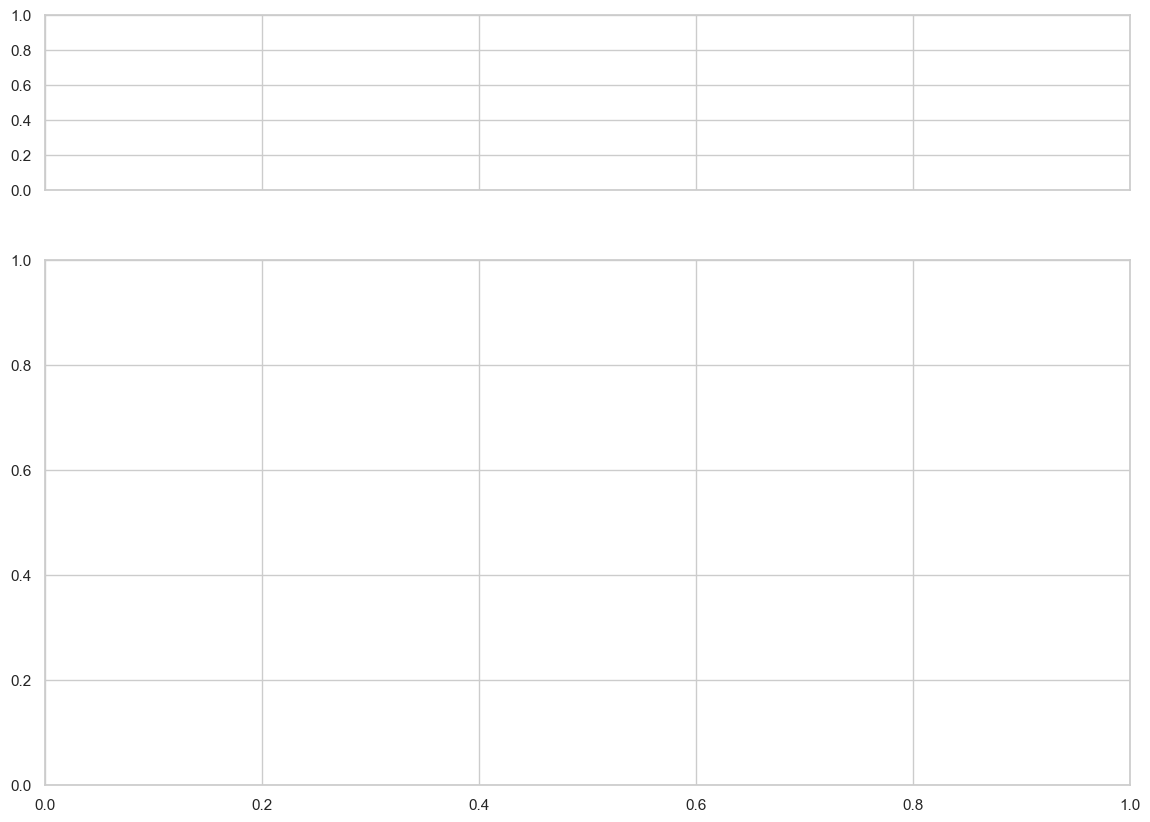

In [72]:
# Drop rows with NaNs in 'env_77_veg' or 'caffeine_percent'
df = df.dropna(subset=['env_77_veg', 'caffeine_percent'])

# Remove rows where 'env_77_veg' is not in the mapping dictionary
df = df[df['env_77_veg'].isin(mapping_dict.keys())]

# Calculate the mean caffeine content for each category in 'env_77_veg'
category_means = df.groupby('env_77_veg')['caffeine_percent'].mean()

# Sort the categories by mean caffeine content in descending order
sorted_categories = category_means.sort_values(ascending=False).index

# Create a new column with the sorted categories
df['env_77_veg_sorted'] = pd.Categorical(df['env_77_veg'], categories=sorted_categories, ordered=True)

# Map the categories to their descriptive labels
df['env_77_veg_mapped'] = df['env_77_veg'].map(mapping_dict)

# Ensure 'env_77_veg_mapped' is also sorted by the mean caffeine content
df['env_77_veg_mapped'] = pd.Categorical(df['env_77_veg_mapped'], categories=[mapping_dict[str(cat)] for cat in sorted_categories], ordered=True)

# Plot
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_77_veg_mapped', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_77_veg_mapped', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')  # Remove default x-axis label
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.show()


In [54]:
print(df[['env_77_veg_mapped', 'caffeine_percent']].head())
print(df[['env_77_veg_mapped', 'caffeine_percent']].isnull().sum())


   env_77_veg_mapped  caffeine_percent
0                NaN              0.00
1                NaN              0.03
2                NaN              0.00
3                NaN              0.00
4                NaN              0.00
env_77_veg_mapped    526
caffeine_percent       0
dtype: int64


In [55]:
unmapped_values = set(df['env_77_veg'].unique()) - set(mapping_dict.keys())
print("Unmapped values:", unmapped_values)


Unmapped values: {1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, nan, 9.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 22.0}


In [56]:
print(df['env_77_veg'].value_counts())
print(df['env_77_veg_mapped'].value_counts())


env_77_veg
16.0    135
14.0     96
5.0      63
6.0      58
7.0      57
15.0     20
12.0     15
4.0      15
22.0     11
9.0       4
1.0       2
3.0       1
2.0       1
13.0      1
11.0      1
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


In [58]:
print("Mapped categories:", df['env_77_veg_mapped'].unique())
print("Caffeine data present:", not df['caffeine_percent'].empty)


Mapped categories: [nan]
Caffeine data present: True


In [59]:
# Ensure 'env_77_veg' is a Categorical with sorted categories
df['env_77_veg'] = pd.Categorical(df['env_77_veg'], categories=sorted_categories, ordered=True)

# Add "Unknown" as a valid category to avoid errors
df['env_77_veg'] = df['env_77_veg'].cat.add_categories(['Unknown'])

# Fill missing values in 'env_77_veg' with "Unknown"
df['env_77_veg'] = df['env_77_veg'].fillna('Unknown')

# Map to descriptive labels and handle unmapped values
df['env_77_veg_mapped'] = df['env_77_veg'].map(mapping_dict)

# If any values are not mapped, fill them with "Unknown"
df['env_77_veg_mapped'] = df['env_77_veg_mapped'].fillna('Unknown')

# Ensure 'caffeine_percent' has valid data
df = df.dropna(subset=['caffeine_percent'])  # Drop rows with missing caffeine_percent


In [60]:
# Check unique categories in the mapped column
print("Mapped categories:", df['env_77_veg_mapped'].unique())

# Check for empty or missing caffeine_percent data
print("Any missing caffeine_percent:", df['caffeine_percent'].isnull().any())


Mapped categories: ['Unknown']
Any missing caffeine_percent: False
